In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from ast import literal_eval

In [2]:
df_test = pd.read_csv("/data/wang/junh/results/Fuse_moe/all_los/multiclass/dynamic_bilevel/TS_CXR_Text_ECG_test_routing.csv")

In [3]:
# Flatten the indices and count occurrences
df_test['indices'] = df_test['indices'].apply(literal_eval)
df_test['experts'] = df_test['indices'].apply(lambda x: [item for sublist in x for item in sublist])
expert_counts = df_test.explode('experts').groupby(['layer_id', 'modality', 'experts']).size().unstack(fill_value=0)


In [4]:
expert_counts

experts             0    1    2    3    4    5    6    7    8    9    10   11  \
layer_id modality                                                               
1        cxr         7    0    8   22  328    2  341  120  376   13  333    0   
         ecg         2    1    0    2  195   63    0    0  357  357  122    1   
         ts         63  167   81  170  252  137  327    0  156    9   82    8   
         txt         0    3  232    0  209  386    0  217  395    0    0    0   
2        cxr         0  331  348    0    0   18  302    0  131    0    0  364   
         ecg         0    0   43    0    0   20  371  105    0    0    4  286   
         ts          0   42   53   20   70   75  279  147   89   26  154  240   
         txt         0    2  386    0  421  728    0    1    0    0    0    0   
3        cxr       166  350    0    0    0    1    0    0   50  123  250    0   
         ecg       351  401  147   13    0    0    0    0    0    2    0  452   
         ts         23  297   13   32   78  114    0    0  105  100  167  266   
         txt         0   42    0  277    0   69    0    0   17  277    0  166   

experts             12   13   14   15  
layer_id modality                      
1        cxr         2    0    0    0  
         ecg        72  356   23    1  
         ts          0    0   61   39  
         txt         0    0    0  110  
2        cxr         0   42   16    0  
         ecg       380  343    0    0  
         ts        296   39   22    0  
         txt         0   14    0    0  
3        cxr        15    0  223  374  
         ecg         0  186    0    0  
         ts         94   78   98   87  
         txt       350    0  354    0

In [5]:
total_experts = expert_counts.sum()

# Normalize to get percentage values for each layer and modality
# Sum along the columns (axis=1), but grouped by 'layer_id' to get total counts for each modality per layer
expert_percentages = expert_counts.div(expert_counts.groupby(level='layer_id').sum(), level='layer_id') * 100

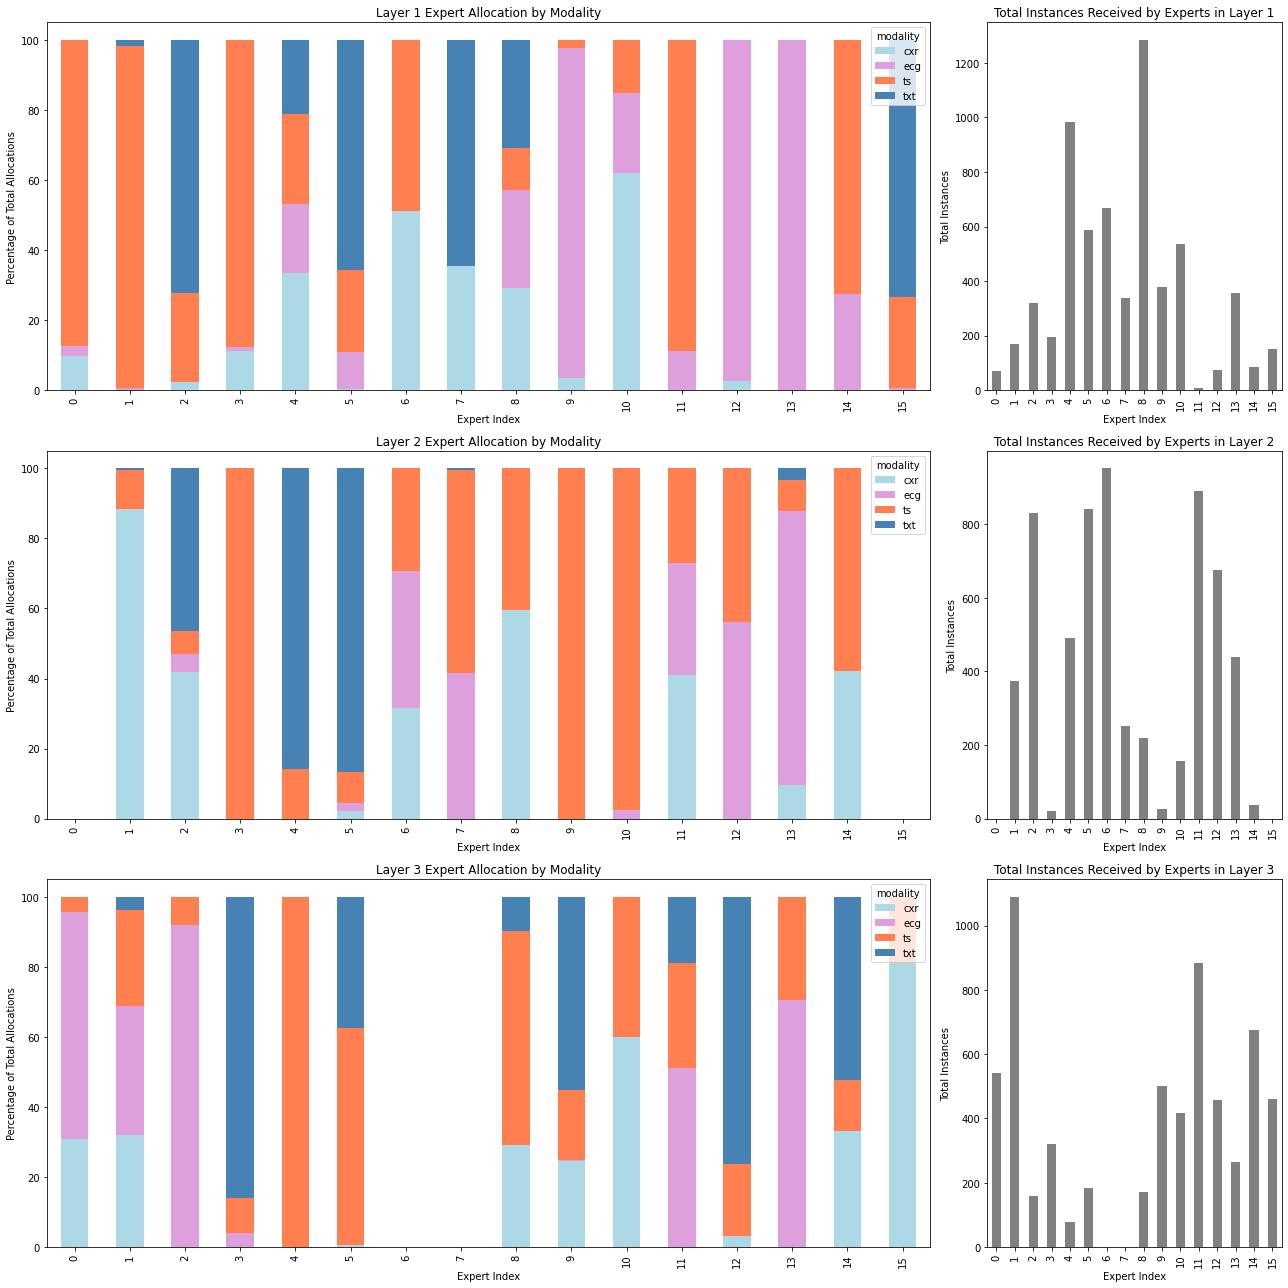

In [6]:
# Plotting setup for visualizing the data
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 18), gridspec_kw={'width_ratios': [3, 1]})

layer_ids = expert_counts.index.get_level_values('layer_id').unique()

for i, layer_id in enumerate(layer_ids):
    ax1 = axes[i, 0]
    # Transpose the data to have experts as rows and modalities as columns, then plot
    layer_data = expert_percentages.xs(layer_id, level='layer_id').T
    layer_data.plot(kind='bar', stacked=True, ax=ax1, title=f"Layer {layer_id} Expert Allocation by Modality", color=['lightblue', 'plum', 'coral', 'steelblue'])
    ax1.set_ylabel("Percentage of Total Allocations")
    ax1.set_xlabel("Expert Index")

    ax2 = axes[i, 1]
    # Calculate total instances for each expert for the current layer only
    total_experts_layer = expert_counts.xs(layer_id, level='layer_id').sum()
    total_experts_layer.plot(kind='bar', ax=ax2, title=f"Total Instances per Expert for Layer {layer_id}", color='gray')
    ax2.set_xlabel("Expert Index")
    ax2.set_ylabel("Total Instances")
    ax2.set_title(f"Total Instances Received by Experts in Layer {layer_id}")

plt.tight_layout()
plt.show()